# Digit Recognition Neural Network Model

In [41]:
# importing essential libraries
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.activations import linear, relu, sigmoid
warnings.filterwarnings("ignore", category=FutureWarning, module="numpy")

In [42]:
# getting MNIST dataset and splitting it to train, validation and test datasets
train_dataset, validation_dataset, test_dataset = tfds.load(
    'mnist',
    split=["train[0%:80%]", "train[80%:100%]", "test"],
    shuffle_files=True,
    as_supervised=True
)

In [43]:
# number of samples in train, validation and test datasets
print(f"Number of training samples: {train_dataset.cardinality()}")
print(f"Number of validation samples: {validation_dataset.cardinality()}")
print(f"Number of test samples: {test_dataset.cardinality()}")

Number of training samples: 48000
Number of validation samples: 12000
Number of test samples: 10000


In [44]:
# checking the shape of input feature and target
for example in train_dataset:
    print("Shape of a digit image:", example[0].shape)
    print("Shape of a label:", example[1].shape)
    break

Shape of a digit image: (28, 28, 1)
Shape of a label: ()


In [45]:
# demonstrating a one sample image with pixel values
for example in train_dataset:
    for i in range(len(example[0])):
        l = tfds.as_numpy(tf.reshape(example[0][i], [-1]))
        for k in range(len(l)):
            if (k == 27):
                print(l[k], end='')
            elif (len(str(l[k+1])) == 1):
                print(l[k], end=' '*3)
            elif (len(str(l[k+1])) == 2):
                print(l[k], end=' '*2)
            elif (len(str(l[k+1])) == 3):
                print(l[k], end=' '*1)
        print()
    break

0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  84 254 101   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 174 253 119   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  31 247 202  29   0   0   0   0   0   0   0   0
0   0   0   0   0   0   0   0   0   1   1   0   0   0   0   0 141 253 168   0   0   0   0   0   0   0   0   0
0   0   0 

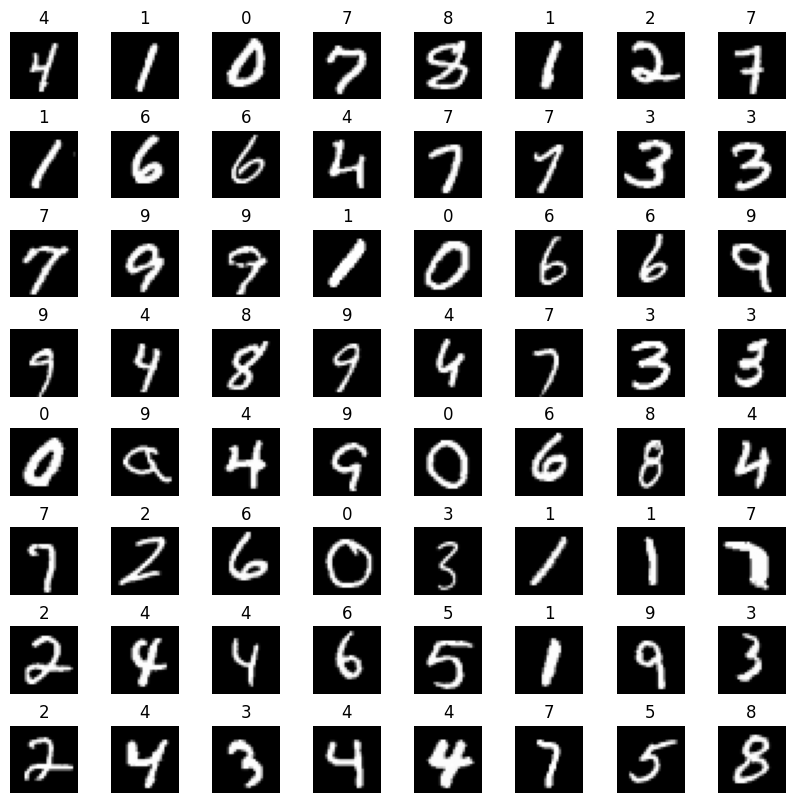

In [46]:
# checking the first 64 samples in the train dataset
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_dataset.take(64)):
    ax = plt.subplot(8, 8, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(int(label))
    plt.axis('off')
plt.subplots_adjust(wspace=0.5, hspace=0.3)

In [47]:
# defining the neural network
tf.random.set_seed(1234)
model = Sequential([
    Flatten(input_shape=(28,28,1), name='F1'),
    Dense(units=25, activation='relu', name='L1'),
    Dense(units=15, activation='relu', name='L2'),
    Dense(units=10, activation='linear', name='L3')
])

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ F1 (Flatten)                    │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L1 (Dense)                      │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,175 (78.81 KB)

 Trainable params: 20,175 (78.81 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# shape of weights in all three layers
[layer0, layer1, layer2, layer3] = model.layers
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (784, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


In [50]:
# configures the training process of the Keras model by defining the essential components:
# the loss function, the optimizer, and the metrics to be tracked
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# the model will process 32 samples at a time before updating its internal parameters.
# model.fit() method will start the training process
batch_size = 32
train_dataset = train_dataset.batch(batch_size)
validation_dataset = validation_dataset.batch(batch_size)
history = model.fit(train_dataset, epochs=40, validation_data=validation_dataset)

Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1366 - loss: 3.5201 - val_accuracy: 0.3159 - val_loss: 1.7771
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3276 - loss: 1.6864 - val_accuracy: 0.5240 - val_loss: 1.2770
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5383 - loss: 1.2050 - val_accuracy: 0.5665 - val_loss: 1.0667
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5777 - loss: 1.0326 - val_accuracy: 0.5967 - val_loss: 0.9940
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6287 - loss: 0.9541 - val_accuracy: 0.7281 - val_loss: 0.8488
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7251 - loss: 0.7705 - val_accuracy: 0.7398 - val_loss: 0.7374
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7778 - loss: 0.6520 - val_accuracy: 0.8171 - val_loss: 0.6323
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8361 - loss: 0.5359 - 

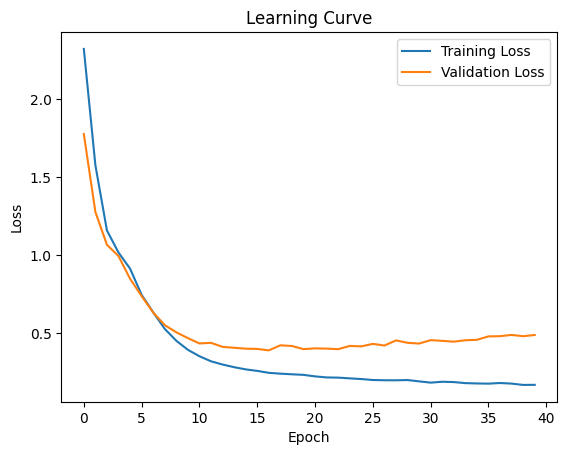

In [51]:
# Plot learning curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()

### Accuracy on Test Dataset

In [55]:
test_dataset_ = test_dataset.batch(batch_size)
predictions = model.predict(test_dataset_)
predicted_labels = np.argmax(predictions, axis=1)

true_labels = []
for images, labels in test_dataset_:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)
correct = np.sum(predicted_labels == true_labels)
wrong = np.sum(predicted_labels != true_labels)

print("Correct predictions:", correct)
print("Wrong predictions:", wrong)
print("Accuracy:", correct / len(true_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step
Correct predictions: 9285
Wrong predictions: 715
Accuracy: 0.9285
